In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("BIKE DETAILS.csv")

Q1. What is the range of selling prices in the dataset?


In [2]:
print("Minimum Selling Price :", df["selling_price"].min())
print("Maximum Selling Price :", df["selling_price"].max())

Minimum Selling Price : 5000
Maximum Selling Price : 760000


Q.2What is the median selling price for bikes in the dataset


In [3]:
df["selling_price"].median()

45000.0

Q3.What is the most common seller type

In [4]:
df["seller_type"].mode()[0]

'Individual'

Q4.How many bikes have driven more than 50,000 kilometers

In [5]:
(df["km_driven"] > 50000).sum()

np.int64(170)

Q5. What is the average km_driven value for each ownership type

In [6]:
df.groupby("owner")["km_driven"].mean()

,km_driven
owner,
1st owner,32816.583333
2nd owner,39288.991870
3rd owner,33292.181818
4th owner,311500.000000


Q6.What proportion of bikes are from the year 2015 or older

In [7]:
(df["year"] <= 2015).mean()*100

np.float64(56.64467483506126)

Q7. What is the trend of missing values across the dataset

In [8]:
df.isnull().sum()

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,435


8. What is the highest ex_showroom_price recorded, and for which bike

In [9]:
df.loc[df["ex_showroom_price"].idxmax()]

,134
name,Harley-Davidson Street Bob
selling_price,750000
year,2013
seller_type,Individual
owner,2nd owner
km_driven,12000
ex_showroom_price,1278000.0


9.What is the total number of bikes listed by each seller type

In [10]:
df["seller_type"].value_counts()

,count
seller_type,
Individual,1055
Dealer,6


Q.10What is the relationship between selling_price and km_driven for first-owner bikes

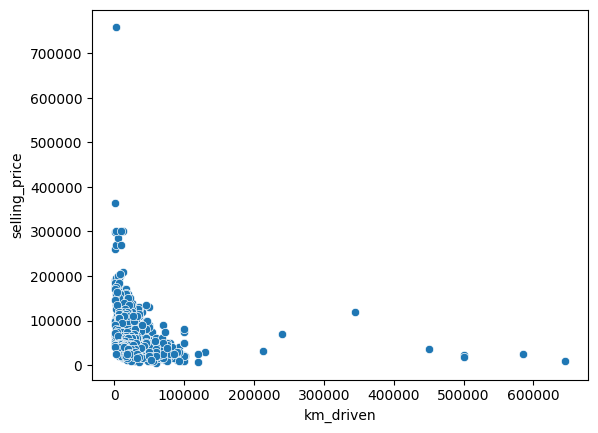

In [11]:
first_owner = df[df["owner"]=="1st owner"]

sns.scatterplot(data=first_owner,
                x="km_driven",
                y="selling_price")

plt.show()

Q11. Identify and remove outliers in the km_driven column using the IQR methodB

In [12]:
Q1 = df["km_driven"].quantile(0.25)
Q3 = df["km_driven"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[(df["km_driven"]<lower) |
              (df["km_driven"]>upper)]

print(len(outliers))

df_clean = df[(df["km_driven"]>=lower) &
              (df["km_driven"]<=upper)]

39


Q12.Perform a bivariate analysis to visualize the relationship between year and selling_priceB

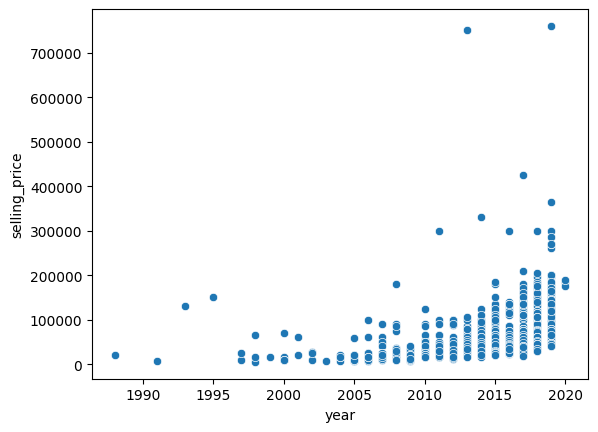

In [13]:
sns.scatterplot(data=df,
                x="year",
                y="selling_price")

plt.show()

Q13.What is the average depreciation in selling price based on the bike's age (current year - manufacturing
year)

Q14. Which bike names are priced significantly above the average price for their manufacturing year

In [14]:
avg_price = df.groupby("year")["selling_price"].transform("mean")

premium = df[df["selling_price"]>avg_price]

premium[["name","year","selling_price"]]

,name,year,selling_price
0,Royal Enfield Classic 350,2019,175000
2,Royal Enfield Classic Gunmetal Grey,2018,150000
3,Yamaha Fazer FI V 2.0 [2016-2018],2015,65000
7,Royal Enfield Bullet 350 [2007-2011],2008,180000
13,Yamaha YZF R3,2019,365000
...,...,...,...
1004,Bajaj Pulsar NS 200,2016,60000
1005,TVS Apache RTR 160,2014,60000
1008,Bajaj Pulsar 220 F,2012,52000
1012,Bajaj Pulsar NS 200,2014,50000


Q15.Develop a correlation matrix for numeric columns and visualize it using a heatmap.

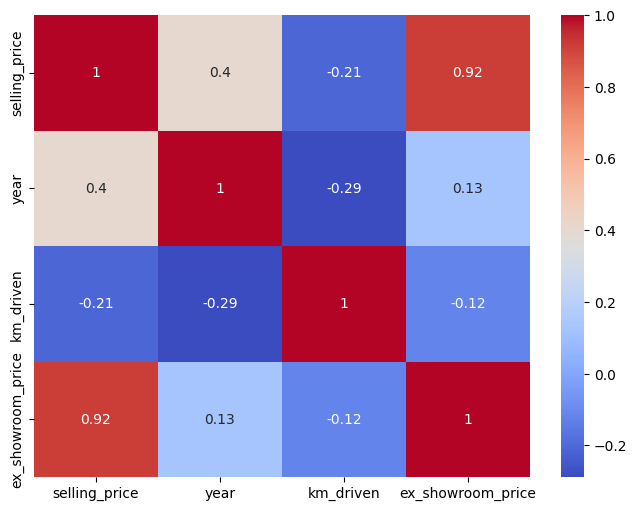

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["selling_price","year","km_driven","ex_showroom_price"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("Car Sale.csv")

Q1. What is the average selling price of cars for each dealer, and how does it compare across different dealers

In [17]:
dealer_avg = df.groupby("Dealer_Name")["Price ($)"].mean().sort_values(ascending=False)
print(dealer_avg)

Dealer_Name
U-Haul CO                                          28769.919006
Classic Chevy                                      28602.014446
Rabun Used Car Sales                               28527.536177
Iceberg Rentals                                    28522.958533
Enterprise Rent A Car                              28312.580800
Scrivener Performance Engineering                  28297.371589
Gartner Buick Hyundai Saab                         28247.621019
Saab-Belle Dodge                                   28190.139888
Capitol KIA                                        28189.703822
Race Car Help                                      28163.372706
Chrysler of Tri-Cities                             28123.091054
Star Enterprises Inc                               28113.055244
Suburban Ford                                      28112.206758
C & M Motors Inc                                   28111.755200
Tri-State Mack Inc                                 28095.562050
Pars Auto Sales             

Q2.Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing
trends

In [18]:
variation = df.groupby("Company")["Price ($)"].std().sort_values(ascending=False)
print(variation)

Company
Lincoln       19658.050211
Saab          19653.740089
Cadillac      19517.120220
Plymouth      19065.997338
Lexus         17852.923492
Buick         17142.232626
Mercury       16445.172195
Nissan        16214.264017
Saturn        15990.223671
Ford          15849.090227
Mercedes-B    15722.807459
Oldsmobile    15711.345857
Toyota        15367.131714
BMW           15065.578723
Pontiac       14348.963592
Infiniti      13696.332844
Chevrolet     13311.063223
Volvo         12933.790185
Subaru        12920.771620
Audi          12904.243867
Volkswagen    12527.124011
Mitsubishi    11671.343035
Chrysler      11583.286811
Dodge         11187.592085
Honda         11148.629062
Jaguar        10222.531533
Jeep           9459.834418
Acura          8183.046414
Porsche        5261.839206
Hyundai        3485.982649
Name: Price ($), dtype: float64


Q3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges
compare

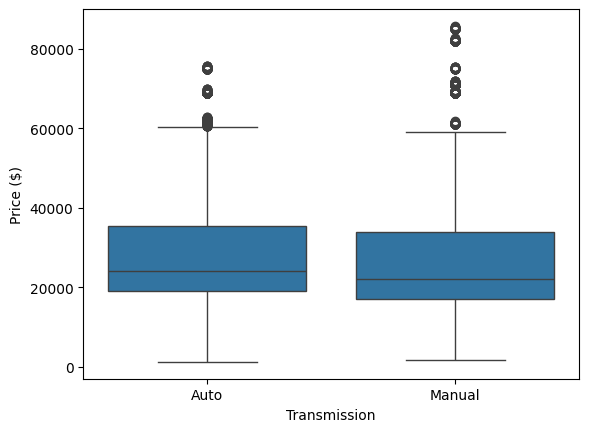

In [19]:
sns.boxplot(data=df,
            x="Transmission",
            y="Price ($)")
plt.show()

Q4. What is the distribution of car prices across different regions

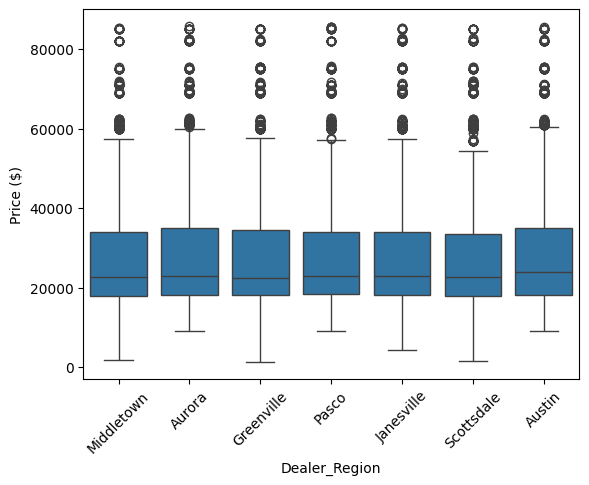

In [20]:
sns.boxplot(data=df,
            x="Dealer_Region",
            y="Price ($)")
plt.xticks(rotation=45)
plt.show()

Q5. What is the distribution of cars based on body styles

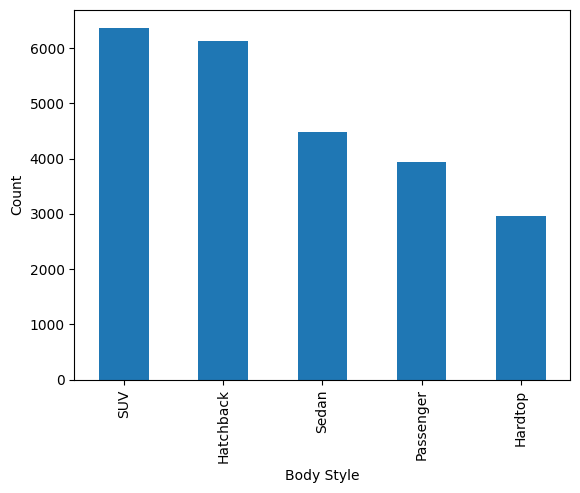

In [21]:
df["Body Style"].value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.show()

Q6.How does the average selling price of cars vary by customer gender and annual income

In [22]:
df.groupby("Gender").agg({
    "Price ($)":"mean",
    "Annual Income":"mean"
})

,Price ($),Annual Income
Gender,,
Female,28277.265270,755973.021339
Male,28039.429407,851184.044207


Q7. What is the distribution of car prices by region, and how does the number of cars sold vary by region

In [23]:
region = df.groupby("Dealer_Region").agg(
    Average_Price=("Price ($)","mean"),
    Cars_Sold=("Car_id","count")
)
print(region)

               Average_Price  Cars_Sold
Dealer_Region                          
Aurora          28334.626837       3130
Austin          28341.603628       4135
Greenville      28180.819054       3128
Janesville      27833.350955       3821
Middletown      27856.338875       3128
Pasco           28119.039923       3131
Scottsdale      27954.958928       3433


Q.8  How does the average car price differ between cars with different engine sizes

In [24]:
df.groupby("Engine")["Price ($)"].mean()

,Price ($)
Engine,
DoubleÂ Overhead Camshaft,28248.525972
Overhead Camshaft,27914.710631


Q9. How do car prices vary based on the customer’s annual income bracket

In [25]:
bins=[0,500000,1000000,1500000,2000000,float("inf")]
labels=["<500K","500K-1M","1M-1.5M","1.5M-2M",">2M"]

df["Income_Bracket"]=pd.cut(df["Annual Income"],
                            bins=bins,
                            labels=labels)

df.groupby("Income_Bracket")["Price ($)"].mean()

/tmp/ipykernel_16259/3351299928.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Income_Bracket")["Price ($)"].mean()


,Price ($)
Income_Bracket,
<500K,28086.588267
500K-1M,28011.726423
1M-1.5M,28196.078886
1.5M-2M,27609.611492
>2M,28970.111857


Q10. What are the top 5 car models with the highest number of sales, and how does their price distribution look

In [26]:
top_models=df["Model"].value_counts().head()

print(top_models)

Model
Diamante      418
Prizm         411
Silhouette    411
Passat        391
Ram Pickup    383
Name: count, dtype: int64


Q.11 How does car price vary with engine size across different car colors, and which colors have the highest price
variation

In [27]:
df.groupby("Color")["Price ($)"].agg(["mean","std"])

,mean,std
Color,,
Black,28564.798015,15286.065976
Pale White,27483.890370,14077.346859
Red,28736.319007,15519.360962


Q.12   Is there any seasonal trend in car sales based on the date of sale

In [28]:
df["Date"]=pd.to_datetime(df["Date"])

df["Month"]=df["Date"].dt.month_name()

df["Month"].value_counts().sort_index()

,count
Month,
April,1655
August,1705
December,3546
February,735
January,790
July,1725
June,1715
March,1535
May,1895


Q13. How does the car price distribution change when considering different combinations of body style and
transmission type

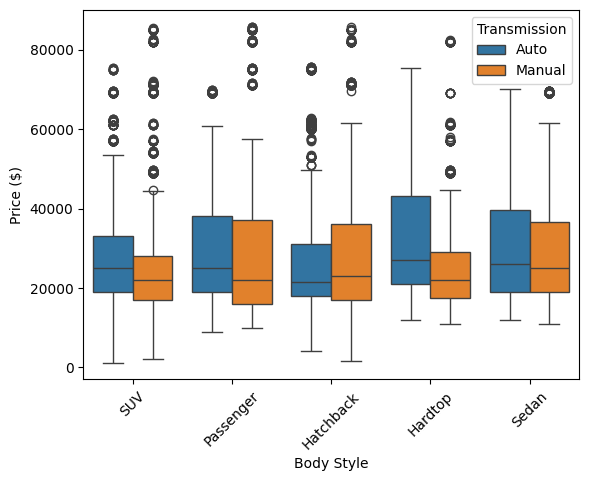

In [29]:
sns.boxplot(data=df,
            x="Body Style",
            y="Price ($)",
            hue="Transmission")
plt.xticks(rotation=45)
plt.show()

Q14. What is the correlation between car price, engine size, and annual income of customers, and how do these
features interact

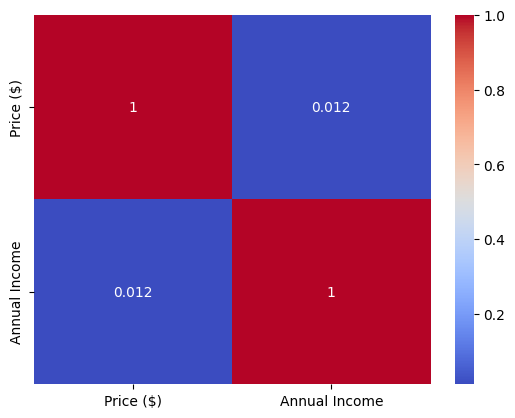

In [30]:
corr=df[["Price ($)","Annual Income"]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()

Q15.How does the average car price vary across different car models and engine types

In [31]:
df.groupby(["Model","Engine"])["Price ($)"].mean()

Model     Engine                   
3-Sep     DoubleÂ Overhead Camshaft    37986.380117
3000GT    DoubleÂ Overhead Camshaft    22764.326923
          Overhead Camshaft            21770.659864
300M      DoubleÂ Overhead Camshaft    21394.888889
323i      DoubleÂ Overhead Camshaft    16744.632287
                                           ...     
Windstar  Overhead Camshaft            17100.272727
Wrangler  DoubleÂ Overhead Camshaft    21145.294737
          Overhead Camshaft            18742.942029
Xterra    DoubleÂ Overhead Camshaft    15940.459459
          Overhead Camshaft            31072.500000
Name: Price ($), Length: 261, dtype: float64

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("amazon.csv")

import pandas as pd
import numpy as np

# Prices
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["actual_price"] = (
    df["actual_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce")
df["actual_price"] = pd.to_numeric(df["actual_price"], errors="coerce")

# Discount percentage
df["discount_percentage"] = (
    df["discount_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

# Rating
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Rating count
df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

Q1.What is the average rating for each product category

Q2. What are the top rating_count products by category

In [33]:
top_products = df.loc[df.groupby("category")["rating_count"].idxmax(),
                      ["category","product_name","rating_count"]]

print(top_products)

                                               category  \
1157  Car&Motorbike|CarAccessories|InteriorAccessori...   
695   Computers&Accessories|Accessories&Peripherals|...   
906   Computers&Accessories|Accessories&Peripherals|...   
748   Computers&Accessories|Accessories&Peripherals|...   
844   Computers&Accessories|Accessories&Peripherals|...   
...                                                 ...   
616   OfficeProducts|OfficePaperProducts|Paper|Stati...   
993   OfficeProducts|OfficePaperProducts|Paper|Stati...   
765   OfficeProducts|OfficePaperProducts|Paper|Stati...   
850   OfficeProducts|OfficePaperProducts|Paper|Stati...   
924   Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...   

                                           product_name  rating_count  
1157  Reffair AX30 [MAX] Portable Air Purifier for C...        1118.0  
695   rts [2 Pack] Mini USB C Type C Adapter Plug, T...        4426.0  
906   Hp Wired On Ear Headphones With Mic With 3.5 M...        7222.0  
748

Q3. What is the distribution of discounted prices vs. actual prices

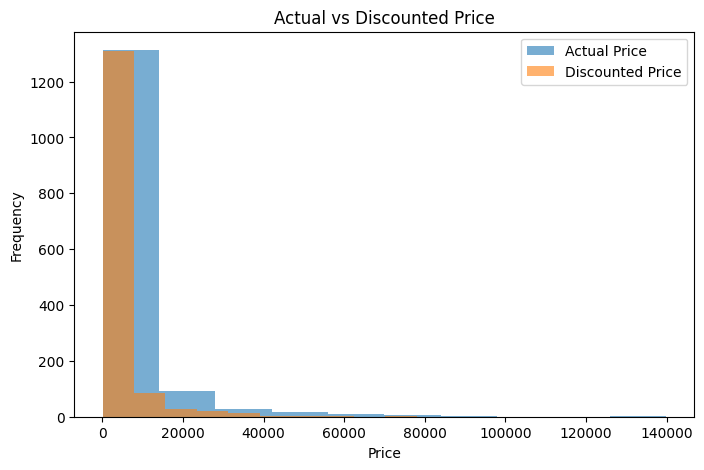

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["actual_price"], alpha=0.6, label="Actual Price")
plt.hist(df["discounted_price"], alpha=0.6, label="Discounted Price")

plt.legend()
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Actual vs Discounted Price")

plt.show()

Q.4  How does the average discount percentage vary across categories

In [35]:
discount = df.groupby("category")["discount_percentage"].mean().sort_values(ascending=False)

print(discount)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors                            90.0
Electronics|Headphones,Earbuds&Accessories|Earpads                                                                    90.0
Electronics|Mobiles&Accessories|MobileAccessories|Décor|PhoneCharms                                                   90.0
Electronics|Headphones,Earbuds&Accessories|Adapters                                                                   88.0
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Keyboard&MiceAccessories|DustCovers         87.5
                                                                                                                      ... 
OfficeProducts|OfficeElectronics|Calculators|Financial&Business                                                        0.0
OfficeProducts|OfficePaperProducts|Paper|Copy&PrintingPaper|ColouredPaper                                              0.0
OfficeP

Q5. What are the most popular product names

In [36]:
df["product_name"].value_counts().head(10)

,count
product_name,
"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution",5
"Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3"",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating",4
"Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)",3
"Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black",3
Flix Micro Usb Cable For Smartphone (Black),3
"Fire-Boltt India's No 1 Smartwatch Brand Talk 2 Bluetooth Calling Smartwatch with Dual Button, Hands On Voice Assistance, 60 Sports Modes, in Built Mic & Speaker with IP68 Rating",3
"Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)",3
"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, Laptops & other Type C devices, PD Technology, 480Mbps Data Sync, Quick Charge 3.0 (RCT15A, Black)",3
"Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini & iOS Devices",3


Q6. What are the most popular product keywords

In [37]:
from collections import Counter

text = " ".join(df["product_name"].astype(str))

words = text.lower().split()

Counter(words).most_common(20)

[('with', 751),
 ('for', 672),
 ('|', 457),
 ('&', 432),
 ('usb', 377),
 ('and', 330),
 ('cable', 320),
 ('-', 220),
 ('charging', 219),
 ('to', 218),
 ('fast', 211),
 ('(black)', 187),
 ('c', 182),
 ('smart', 171),
 ('type', 144),
 ('compatible', 138),
 ('tv', 138),
 ('data', 131),
 ('hd', 130),
 ('in', 118)]

Q7. What are the most popular product reviews

In [38]:
df["review_title"].value_counts().head(10)

,count
review_title,
"Worked on iPhone 7 and didn’t work on XR,Good one,Dull Physical Looks,Just Buy it,Go for it,About the product,Get charging cable at the price,Working well.",10
"Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good Product,As of now seems good",8
"Phone, camera, heating - works for me, may not for all,Good Mobile,Good but not excellent under this budget,Worth the price at 9499,Ok type phone... but unable to make videocall within same service provider.,Phone review,Budget king,Battery backup is good",8
"A Good Braided Cable for Your Type C Device,Good quality product from ambrane,Super cable,As,Good quality,Good product,its good,Good quality for the price but one issue with my unit",7
"Good product,Good one,Nice,Really nice product,Very first time change,Good,Fine product but could be better,Very nice it's charging like jet",7
"Above average phone,Worth For The Money 💰,Okie,Phone is excellent,Purchased in good budget at 12k,It can fulfill basic needs in affordable price range,Nice,About features",6
"Fake Product,Costly but excellent quality,Storage good but don't know how to Activate warantee??,Good for use,5 stas nahi diya kyuki capacity 477gb hi rahta hai,Speed not as advertise,Good one,It's ok",6
"The metal pin is losing it's strength,Sahi h bs 44 rupe ki and dilivery charge 40,Good Charging cable,Good sturdy micro usb cable with good charging speeds,Cheapest micro USB cable in the market,boat is better than this,I bought this for 199rs best charging cable for all mobiles,Good",5
"GOOD,Thank you Amazon very good charging cable,Good,Very good product,good quality,Very Good Product,This is fast charging USB!,Simply perfect at the price of below 100",5


Q.8  What is the correlation between discounted_price and rating

                  discounted_price    rating
discounted_price          1.000000  0.120337
rating                    0.120337  1.000000


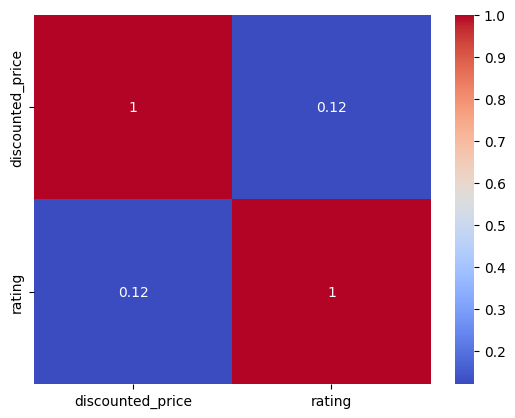

In [39]:
corr = df[["discounted_price","rating"]].corr()

print(corr)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

Q.9 ' What are the Top 5 categories based on the highest ratings

In [40]:
top5 = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

print(top5)

category
Computers&Accessories|Tablets                                               4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters    4.5
Electronics|Cameras&Photography|Accessories|Film                            4.5
Computers&Accessories|Components|Memory                                     4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                4.5
Name: rating, dtype: float64


Q10. Identify any potential areas for improvement or optimization based on the data analysis.

In [41]:
low_rating = df[df["rating"] < 3.5][
    ["product_name","category","rating"]
]

print(low_rating.head(20))

                                          product_name  \
45   Wecool Nylon Braided Multifunction Fast Chargi...   
82   SKYWALL 81.28 cm (32 inches) HD Ready Smart LE...   
142  LRIPL Mi Remote Control with Netflix & Prime V...   
154  GENERIC Ultra-Mini Bluetooth CSR 4.0 USB Dongl...   
179  7SEVEN® Bluetooth Voice Command Remote for Xia...   
236  7SEVEN® TCL Remote Control Smart TV RC802V Rem...   
263  7SEVEN Compatible LG TV Remote Suitable for LG...   
275  LOHAYA Voice Assistant Remote Compatible for A...   
282  Amazon Brand - Solimo 65W Fast Charging Braide...   
290                                   Firestick Remote   
318  7SEVEN® Compatible with Fire Tv Stick Remote w...   
463  PTron Newly Launched Force X10 Bluetooth Calli...   
492  PTron Newly Launched Force X10 Bluetooth Calli...   
506  PTron Newly Launched Force X10 Bluetooth Calli...   
545  SHREENOVA ID116 Plus Bluetooth Fitness Smart W...   
550  Tokdis MX-1 Pro Bluetooth Calling Smartwatch -...   
744  Zebronics

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("spotify.csv")

Q.1Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do
the needful

In [43]:
# Check dataset information
df.info()

# Null values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB

Missing Values:
Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64

Duplicate Rows: 27

Shape after removing duplicates: (413, 5)


Q.2 What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram

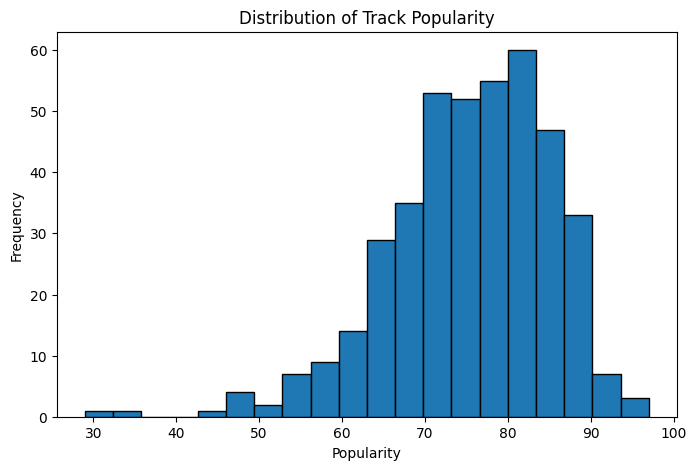

In [44]:
plt.figure(figsize=(8,5))

plt.hist(df["Popularity"], bins=20, edgecolor="black")

plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.show()

Q.3 Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot

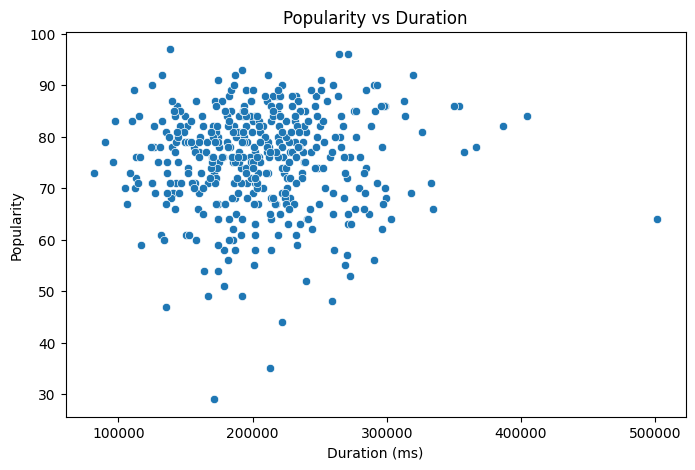

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Duration (ms)",
    y="Popularity"
)

plt.title("Popularity vs Duration")

plt.show()

Q4.Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using
a countplot

Artist
Drake          17
Eminem         11
Lil Nas X      10
JAY-Z          10
21 Savage      10
               ..
Lil Tjay        1
BigXthaPlug     1
Fat Joe         1
A$AP Ferg       1
Diddy           1
Name: count, Length: 115, dtype: int64


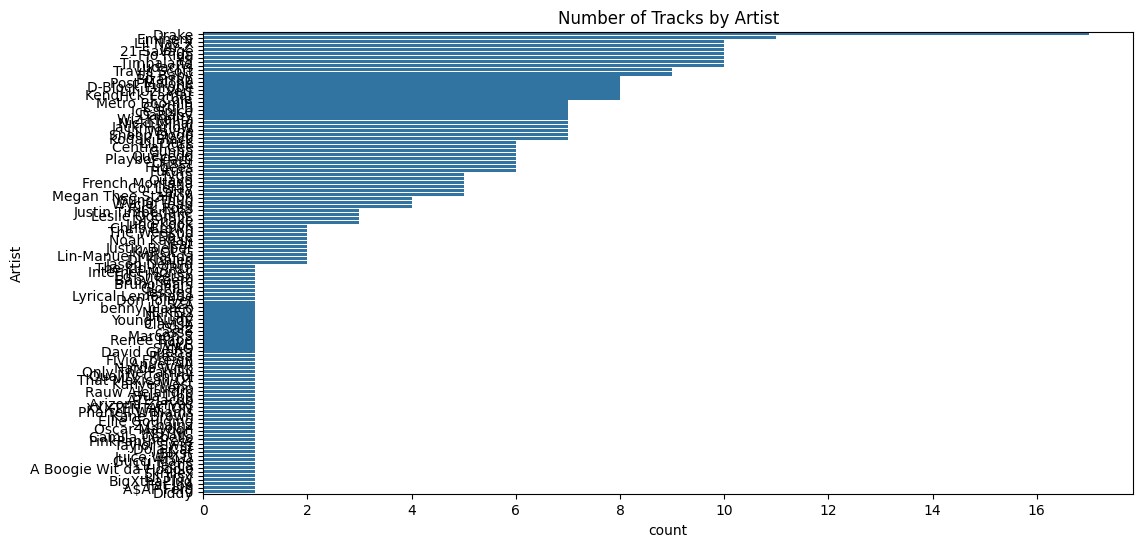

In [46]:
artist_count = df["Artist"].value_counts()

print(artist_count)

plt.figure(figsize=(12,6))

sns.countplot(
    y="Artist",
    data=df,
    order=df["Artist"].value_counts().index
)

plt.title("Number of Tracks by Artist")

plt.show()

Q.5 What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each

In [47]:
least_popular = df.nsmallest(
    5,
    "Popularity"
)[["Artist","Track Name","Popularity"]]

print(least_popular)

             Artist                     Track Name  Popularity
207          Pressa  Attachments (feat. Coi Leray)          29
231   Justin Bieber                     Intentions          35
413  French Montana                Splash Brothers          44
225        Lil Baby                  On Me - Remix          47
407     Wyclef Jean      911 (feat. Mary J. Blige)          48


Q6.Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and
display the average popularity for each artist

In [48]:
top_artists = df["Artist"].value_counts().head(5).index

avg_popularity = (
    df[df["Artist"].isin(top_artists)]
    .groupby("Artist")["Popularity"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_popularity)

Artist
21 Savage    83.800000
Eminem       83.636364
Drake        82.882353
JAY-Z        77.900000
Lil Nas X    75.900000
Name: Popularity, dtype: float64


Q.7 For the top 5 most popular artists, what are their most popular tracks? List the track name for each artis

In [49]:
top_tracks = (
    df[df["Artist"].isin(top_artists)]
    .sort_values("Popularity", ascending=False)
    .groupby("Artist")
    .first()[["Track Name","Popularity"]]
)

print(top_tracks)

                                        Track Name  Popularity
Artist                                                        
21 Savage                                   redrum          96
Drake      Rich Baby Daddy (feat. Sexyy Red & SZA)          92
Eminem                                  Without Me          90
JAY-Z                              Ni**as In Paris          86
Lil Nas X                        THATS WHAT I WANT          81


Q.8 Visualize relationships between multiple numerical variables simultaneously using a pair plot

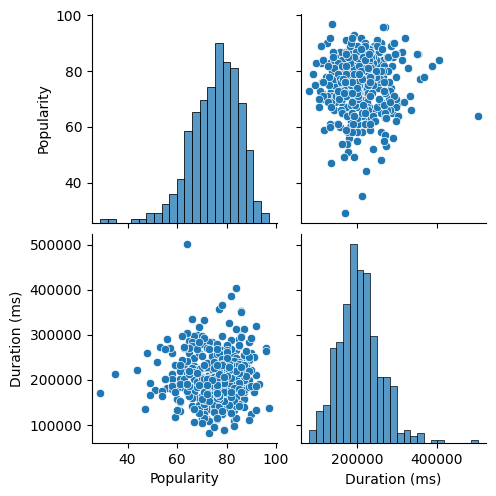

In [50]:
sns.pairplot(
    df[["Popularity","Duration (ms)"]]
)

plt.show()

Q.9 Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or
violin plot

In [ ]:
top10 = df["Artist"].value_counts().head(10).index

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[df["Artist"].isin(top10)],
    x="Artist",
    y="Duration (ms)"
)

plt.xticks(rotation=45)

plt.show()

Q10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a
violin plot.

In [52]:
# Top 10 artists based on number of tracks
top10 = df["Artist"].value_counts().head(10).index

print(top10)

Index(['Drake', 'Eminem', 'Lil Nas X', 'JAY-Z', '21 Savage', 'Flo Rida', '¥$',
       'Timbaland', 'Ludacris', 'Travis Scott'],
      dtype='object', name='Artist')


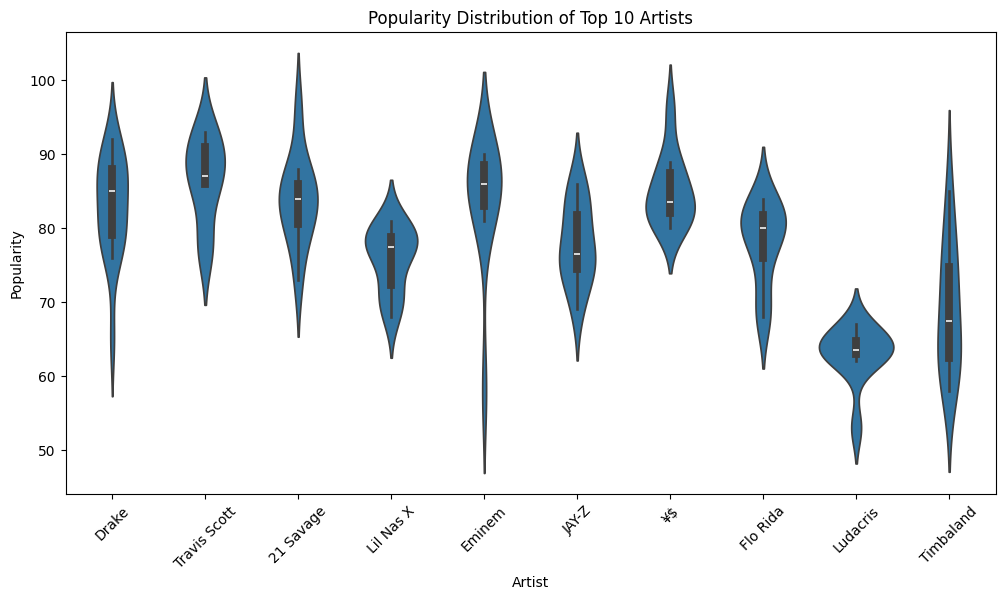

In [53]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df[df["Artist"].isin(top10)],
    x="Artist",
    y="Popularity"
)

plt.xticks(rotation=45)
plt.title("Popularity Distribution of Top 10 Artists")
plt.show()